In [89]:
import torch
#Vérification cuda
print("CUDA disponible :", torch.cuda.is_available())
print("Nombre de GPU :", torch.cuda.device_count())
print("Nom du GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun GPU disponible")

CUDA disponible : True
Nombre de GPU : 1
Nom du GPU : NVIDIA GeForce RTX 2080


## 1) Data Exploration

### Chargement du dataset

In [90]:
from medmnist import PathMNIST
import os
import numpy as np

# Créer dossier dataset si besoin
os.makedirs("dataset", exist_ok=True)

# Charger les splits
train_dataset = PathMNIST(split="train", root="dataset", download=True)
val_dataset   = PathMNIST(split="val", root="dataset", download=True)
test_dataset  = PathMNIST(split="test", root="dataset", download=True)

# Informations générales
print("---- DATASET STRUCTURE ----")
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

# Exemple d’un sample
image, label = train_dataset[0]

print("\n---- SAMPLE INFO ----")
print("Image type:", type(image))
print("Image shape:", np.array(image).shape)
print("Label:", label)
print("Label type:", type(label))

Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
---- DATASET STRUCTURE ----
Train size: 89996
Validation size: 10004
Test size: 7180

---- SAMPLE INFO ----
Image type: <class 'PIL.Image.Image'>
Image shape: (28, 28, 3)
Label: [0]
Label type: <class 'numpy.ndarray'>


Le dataset PathMNIST contient 107 180 images déjà séparées en trois ensembles : 89 996 images pour l’entraînement, 10 004 pour la validation et 7 180 pour le test. Cette séparation permet d’entraîner le modèle, de régler les hyperparamètres et d’évaluer les performances de manière rigoureuse.

Chaque échantillon est une image au format PIL (Python Imaging Library) représentant une image RGB de taille 28×28 pixels, ce qui signifie qu’elle possède trois canaux de couleur (rouge, vert et bleu). Les étiquettes sont stockées sous forme de tableaux NumPy et correspondent à une classification multi-classe, où chaque image appartient à une catégorie parmi plusieurs possibles.

Cette analyse confirme que le dataset est prêt à être utilisé pour un problème de classification d’images.

### Nombre d'images par labal dans le split test

In [91]:
import numpy as np
from collections import Counter
from medmnist import INFO

# Infos officielles
info = INFO['pathmnist']
class_names = info['label']

# Récupérer tous les labels du train set
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])

# Si les labels sont en format [[0]], on les aplatie
train_labels = train_labels.flatten()

# Compter
label_counts = Counter(train_labels)

print("---- CLASS DISTRIBUTION (TRAIN SET) ----")
for label in sorted(label_counts.keys()):
    print(f"{label} ({class_names[str(label)]}): {label_counts[label]}")

---- CLASS DISTRIBUTION (TRAIN SET) ----
0 (adipose): 9366
1 (background): 9509
2 (debris): 10360
3 (lymphocytes): 10401
4 (mucus): 8006
5 (smooth muscle): 12182
6 (normal colon mucosa): 7886
7 (cancer-associated stroma): 9401
8 (colorectal adenocarcinoma epithelium): 12885


### Distribution des classes (graphiquement)

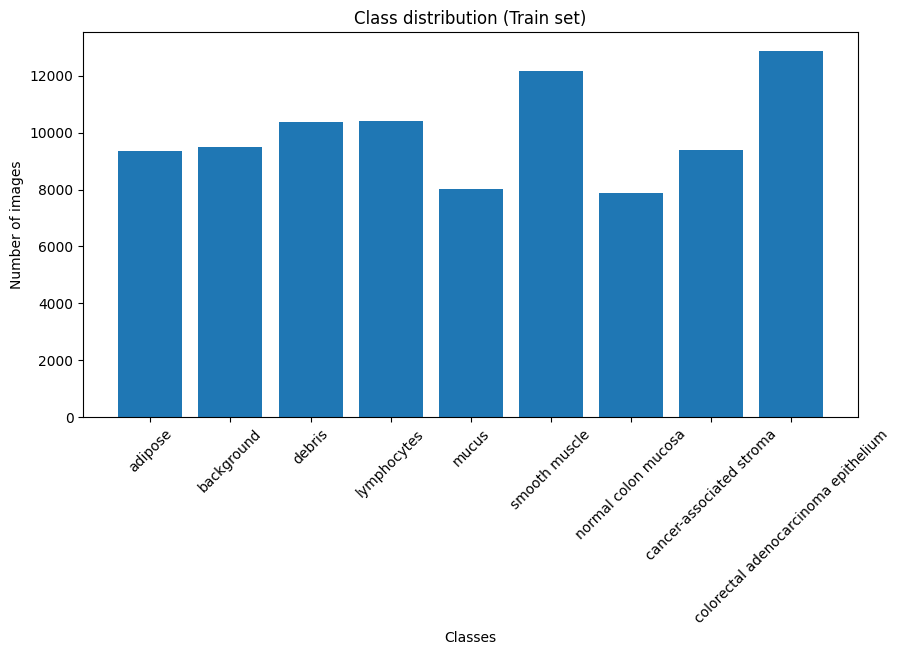

In [92]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from medmnist import INFO

# Noms des classes officiels
info = INFO['pathmnist']
class_names = info['label']

# Récupérer les labels du train set
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])
train_labels = train_labels.flatten()

# Compter les occurrences
counts = Counter(train_labels)

# Préparer les données pour le graphique
labels = sorted(counts.keys())
values = [counts[l] for l in labels]
names = [class_names[str(l)] for l in labels]

# Plot
plt.figure(figsize=(10,5))
plt.bar(names, values)
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Class distribution (Train set)")
plt.xticks(rotation=45)
plt.show()

### Afficher plusieurs images par classe

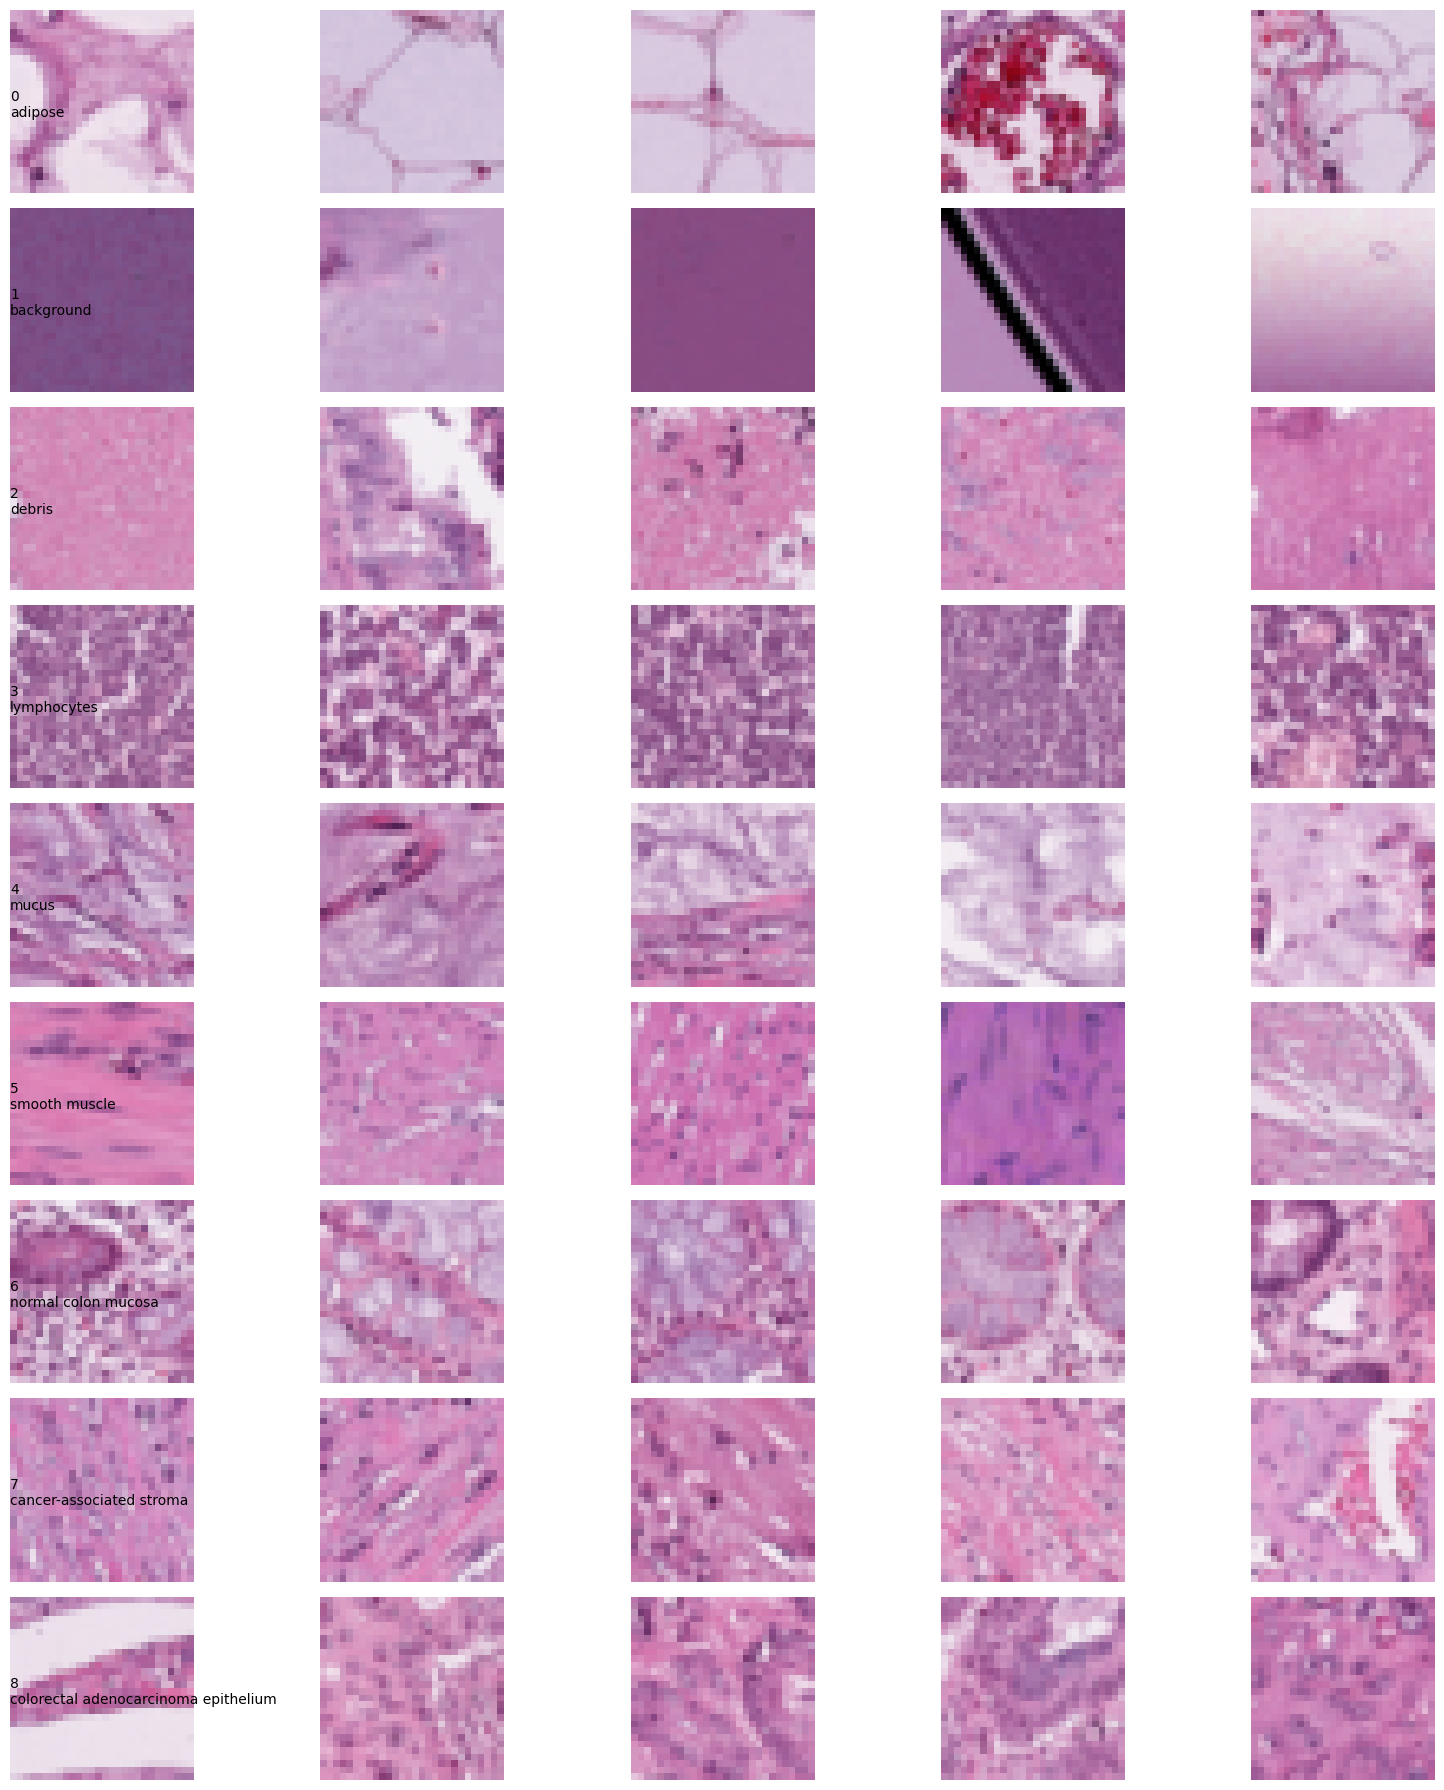

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# Infos classes
info = INFO['pathmnist']
class_names = info['label']
num_classes = len(class_names)

# Labels train
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])
train_labels = train_labels.flatten()

images_per_class = 5

plt.figure(figsize=(15, 18))

for class_idx in range(num_classes):
    
    # Indices de la classe
    indices = np.where(train_labels == class_idx)[0]
    
    # Sélection de 5 images
    selected = np.random.choice(indices, images_per_class, replace=False)
    
    for j, idx in enumerate(selected):
        image, label = train_dataset[idx]
        
        plt.subplot(num_classes, images_per_class,
                    class_idx * images_per_class + j + 1)
        
        plt.imshow(image)
        plt.axis("off")
        
        # Affichage du nom uniquement sur la première colonne
        if j == 0:
            plt.text(-0.5, 14,  # position ajustable
                     f"{class_idx}\n{class_names[str(class_idx)]}",
                     fontsize=10,
                     verticalalignment='center')

plt.tight_layout()
plt.show()

#### Question Q1.1

On observe entre la classe "background" et "debris" des différences majeures. Les textures de la classe "background" sont plus uniformes, on a l'impression d'un fond couleur unique, d'ailleurs souvent très clair ou très foncé. Les textures de la classe "debris" sont davantage disparates et d'une couleur rose qui semble être une moyenne entre le violet foncé et le rose très clair de la classe "background".

#### Question Q1.2

Calcul sur une image unique :

In [94]:
import numpy as np
import torch

# 1️⃣ Prendre une image du train set
image, label = train_dataset[0]

# Convertir en numpy array
image = np.array(image)

# Normaliser en float
image = image.astype(np.float32) / 255.0

# 2️⃣ Calcul mean et std par canal
mean_R = np.mean(image[:, :, 0])
mean_G = np.mean(image[:, :, 1])
mean_B = np.mean(image[:, :, 2])

std_R = np.std(image[:, :, 0])
std_G = np.std(image[:, :, 1])
std_B = np.std(image[:, :, 2])

print("Pixel intensity statistics (single image):")
print(f"Mean  - R: {mean_R:.4f}, G: {mean_G:.4f}, B: {mean_B:.4f}")
print(f"Std   - R: {std_R:.4f}, G: {std_G:.4f}, B: {std_B:.4f}")

Pixel intensity statistics (single image):
Mean  - R: 0.8594, G: 0.8025, B: 0.8814
Std   - R: 0.0176, G: 0.0325, B: 0.0230


Statistiques ImageNet : <bR>
Mean = [0.485, 0.456, 0.406]<br>
Std  = [0.229, 0.224, 0.225]

L’image PathMNIST sélectionnée présente des intensités moyennes nettement supérieures aux moyennes d’ImageNet. Les écarts-types sont significativement plus faibles que ceux d’ImageNet, ce qui indique une très faible variabilité des pixels. Cette image est donc beaucoup plus lumineuse et homogène que les images naturelles typiques d’ImageNet. Ces différences sont attendues, car PathMNIST contient des images avec des motifs de coloration spécifiques, contrairement aux scènes naturelles variées présentes dans ImageNet.

## 2) Dense Network Baseline


### Architecture

### Définition de l'Architecture (MLP)

Nous implémentons un **Perceptron Multi-Couches (MLP)** simple. Ce modèle aplatit l'image d'entrée (28x28x3) en un vecteur de 2352 caractéristiques, puis utilise des couches linéaires (`Linear`) avec des fonctions d'activation ReLU et du Dropout pour limiter le surapprentissage.

In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(28*28*3, 512)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, 9)  # 9 classes PathMNIST
        
    def forward(self, x):
        x = self.flatten(x)
        
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        x = self.fc3(x)
        
        return x

### Chargement Optimisé en VRAM

Pour maximiser l'utilisation du GPU et éviter les goulots d'étranglement liés aux transferts CPU/GPU à chaque batch, nous chargeons l'intégralité du dataset directement dans la mémoire vidéo (VRAM). Les données sont normalisées et converties en tenseurs PyTorch une seule fois.

In [96]:
from torchvision import transforms
from medmnist import PathMNIST
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

def load_to_vram(split):
    dataset = PathMNIST(split=split, root="dataset", download=True)
    # Passage en (N, C, H, W) et envoi sur le bon périphérique
    imgs = torch.from_numpy(dataset.imgs).permute(0, 3, 1, 2).float().to(device) / 255.0
    imgs = (imgs - 0.5) / 0.5
    labels = torch.from_numpy(dataset.labels).flatten().long().to(device)
    return imgs, labels

x_train, y_train = load_to_vram('train')
x_val, y_val     = load_to_vram('val')
x_test, y_test   = load_to_vram('test')
print("Données chargées et prêtes.")

Device utilisé : cuda
Utilisation de : cuda
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Données chargées et prêtes.


### Boucle d'Entraînement

L'entraînement s'effectue sur 20 époques avec un optimiseur **Adam** et une taille de batch de 2048. À chaque époque, nous mélangeons les données et calculons la perte (`Loss`) ainsi que la précision (`Accuracy`) pour les ensembles d'entraînement et de validation. Ces métriques sont stockées pour une analyse ultérieure.

In [97]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

num_epochs = 20
batch_size = 2048

train_losses, val_losses = [], []
train_accs, val_accs     = [], []

print(f"Entraînement sur {device}...")
for epoch in range(num_epochs):
    model.train()
    indices = torch.randperm(x_train.size(0), device=device)
    running_loss = 0.0
    correct, total = 0, 0
    
    for i in range(0, x_train.size(0), batch_size):
        batch_idx = indices[i:i+batch_size]
        images, labels = x_train[batch_idx], y_train[batch_idx]

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / x_train.size(0))
    train_accs.append(correct / total)

    # Validation
    model.eval()
    with torch.no_grad():
        outputs = model(x_val)
        v_loss = criterion(outputs, y_val)
        val_losses.append(v_loss.item())
        
        _, predicted = torch.max(outputs, 1)
        val_acc = (predicted == y_val).sum().item() / y_val.size(0)
        val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_acc:.4f}")

Entraînement sur cuda...
Epoch 1/20 | Train Acc: 0.3289 | Val Acc: 0.3891
Epoch 2/20 | Train Acc: 0.4336 | Val Acc: 0.5126
Epoch 3/20 | Train Acc: 0.5080 | Val Acc: 0.5438
Epoch 4/20 | Train Acc: 0.5345 | Val Acc: 0.5513
Epoch 5/20 | Train Acc: 0.5491 | Val Acc: 0.5748
Epoch 6/20 | Train Acc: 0.5600 | Val Acc: 0.5782
Epoch 7/20 | Train Acc: 0.5675 | Val Acc: 0.5865
Epoch 8/20 | Train Acc: 0.5750 | Val Acc: 0.5839
Epoch 9/20 | Train Acc: 0.5813 | Val Acc: 0.5963
Epoch 10/20 | Train Acc: 0.5892 | Val Acc: 0.6044
Epoch 11/20 | Train Acc: 0.5949 | Val Acc: 0.6081
Epoch 12/20 | Train Acc: 0.5974 | Val Acc: 0.6091
Epoch 13/20 | Train Acc: 0.6031 | Val Acc: 0.6153
Epoch 14/20 | Train Acc: 0.6070 | Val Acc: 0.6112
Epoch 15/20 | Train Acc: 0.6154 | Val Acc: 0.6178
Epoch 16/20 | Train Acc: 0.6195 | Val Acc: 0.6155
Epoch 17/20 | Train Acc: 0.6257 | Val Acc: 0.6281
Epoch 18/20 | Train Acc: 0.6319 | Val Acc: 0.6320
Epoch 19/20 | Train Acc: 0.6362 | Val Acc: 0.6307
Epoch 20/20 | Train Acc: 0.6384 | 

### Visualisation de la Convergence

Nous affichons les courbes de perte (Loss) et de précision (Accuracy) pour vérifier si le modèle converge correctement et s'il présente des signes de surapprentissage (overfitting).

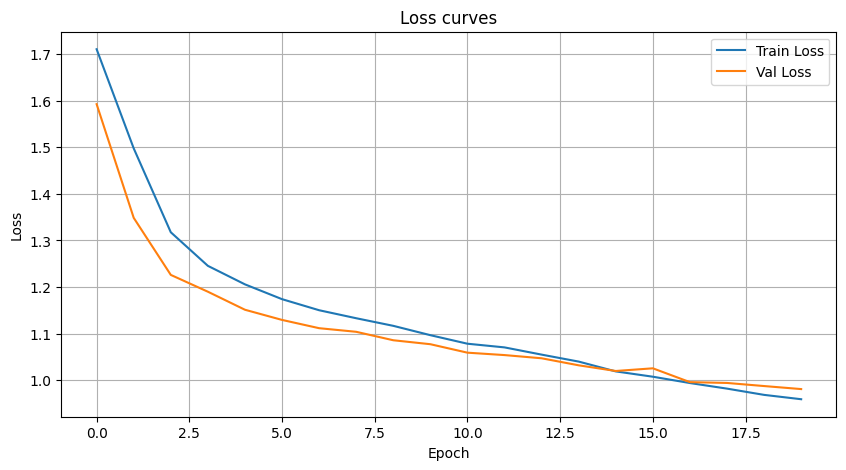

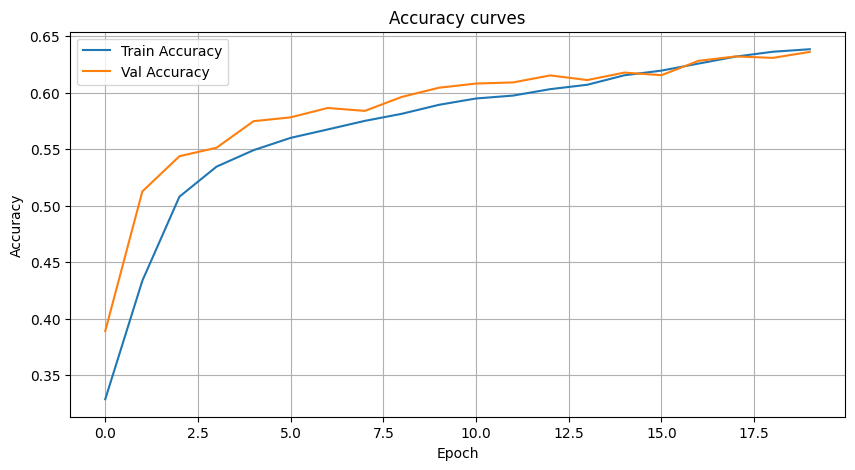

In [98]:
import matplotlib.pyplot as plt

# Courbes de perte
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.grid(True)
plt.show()

# Courbes de précision
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.grid(True)
plt.show()

### Matrice de Confusion

Pour une évaluation plus détaillée, nous calculons la matrice de confusion sur l'ensemble de test. Cela permet de voir quelles classes sont les plus difficiles à distinguer pour le modèle.

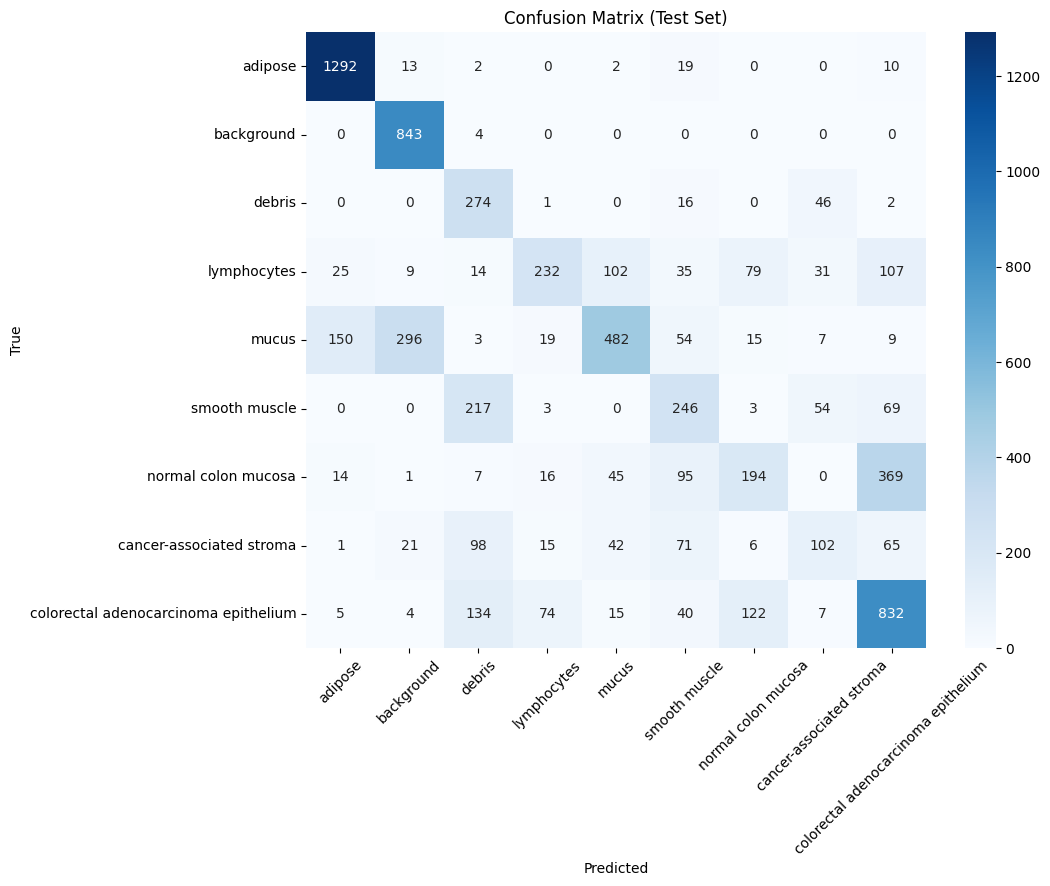

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
with torch.no_grad():
    outputs = model(x_test)
    _, predicted = torch.max(outputs, 1)
    
    all_preds = predicted.cpu().numpy()
    all_labels = y_test.cpu().numpy()

cm = confusion_matrix(all_labels, all_preds)
classes = [class_names[str(i)] for i in range(len(class_names))]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.show()